In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [2]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/newsvendor_1d")
# assert experiment_dir.exists()
# newsvendor_1d_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
# with open(experiment_dir / "experiment.json", "r") as json_file:
#     experiment = json.load(json_file)

# # check the number of train/test observations is the same:
# assert len(newsvendor_1d_df["num_observations"].unique()) == 1
# assert len(newsvendor_1d_df["num_test_observations"].unique()) == 1

# # now we are going to edit/update the old results file
# newsvendor_1d_df = newsvendor_1d_df.loc[newsvendor_1d_df["posterior"] == "bayes"]
# newsvendor_1d_df["posterior"] = "gamma"
# newsvendor_1d_df["likelihood"] = "exponential"
# newsvendor_1d_df["inference"] = "bayes"
# newsvendor_1d_df["setup_time"] = np.nan
# newsvendor_1d_df["algorithm"] = "kl_bdro"

# newsvendor_1d_df

In [21]:
experiment_dir = Path("/dcs/large/u1508153/misdro/exp_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
with open(experiment_dir / "experiment.json", "r") as json_file:
    experiment = json.load(json_file)

# check the number of train/test observations is the same:
assert len(results_df["num_observations"].unique()) == 1
assert len(results_df["num_test_observations"].unique()) == 1

n_total_samples_sqrt = 50
results_df = results_df.loc[(
    (results_df["num_likelihood_samples"] == n_total_samples_sqrt) & (results_df["num_posterior_samples"] == n_total_samples_sqrt)
    | (results_df["num_likelihood_samples"] == n_total_samples_sqrt ** 2) & (results_df["num_posterior_samples"] == 1)
)]
results_df

mean_cost      var_cost  \
uuid                                 replication                             
acacc82a-b8b9-47be-9211-c8d6c27f4d66 0             77.492427   1542.499028   
                                     1            102.173670  33028.181418   
                                     2             59.946728   4130.775844   
                                     3             91.491652  13257.602400   
                                     4            101.852462  12208.283169   
...                                                      ...           ...   
275680e4-2d0f-4374-a101-a403dce668d7 195          103.124988    671.207351   
                                     196          119.400183    472.504976   
                                     197          100.148890    706.347418   
                                     198           85.589217    441.643613   
                                     199          109.656212    593.146184   

                                                   solution  dgp_time  \
uuid                                 replication                        
acacc82a-b8b9-47be-9211-c8d6c27f4d66 0            38.437147  0.000172   
                                     1            27.489624  0.000168   
                                     2            24.768005  0.000172   
                                     3            24.482764  0.000165   
                                     4            38.324362  0.000166   
...                                                     ...       ...   
275680e4-2d0f-4374-a101-a403dce668d7 195          46.651341  0.000554   
                                     196          50.000000  0.000544   
                                     197          48.019345  0.000543   
                                     198          39.544048  0.000543   
                                     199          50.000000  0.000551   

                                                  likelihood_time  \
uuid                                 replication                    
acacc82a-b8b9-47be-9211-c8d6c27f4d66 0                   0.000102   
                                     1                   0.000101   
                                     2                   0.000102   
                                     3                   0.000099   
                                     4                   0.000108   
...                                                           ...   
275680e4-2d0f-4374-a101-a403dce668d7 195                 0.002678   
                                     196                 0.002638   
                                     197                 0.002667   
                                     198                 0.002700   
                                     199                 0.002682   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
acacc82a-b8b9-47be-9211-c8d6c27f4d66 0                  0.000027    0.718326   
                                     1                  0.000028    0.687733   
                                     2                  0.000028    0.756002   
                                     3                  0.000028    0.702892   
                                     4                  0.000027    0.675777   
...                                                          ...         ...   
275680e4-2d0f-4374-a101-a403dce668d7 195                0.000105    0.571955   
                                     196                0.000104    0.547897   
                                     197                0.000105    0.583416   
                                     198                0.000103    0.607128   
                                     199                0.000104    0.559765   

                                                  setup_time    algorithm  \
uuid                                 replication                      

In [22]:
# assert not set(results_df.columns).difference(newsvendor_1d_df.columns)
# results_df = pd.concat([results_df, newsvendor_1d_df])

In [23]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                mean   
algorithm   dgp              epsilon inference posterior               
kl_bdro     contaminated_exp 0.001   bayes     gamma      112.905560   
            exponential      0.001   bayes     gamma      103.486816   
                             0.002   bayes     gamma      103.493935   
                             0.005   bayes     gamma      103.514835   
                             0.010   bayes     gamma      103.548898   
...                                                              ...   
kl_dro_bas truncated_normal 1.000   bayes     gamma       80.672648   
                             1.500   bayes     gamma      107.391206   
                             2.000   bayes     gamma      110.868603   
                             2.500   bayes     gamma      111.012604   
                             3.000   bayes     gamma      111.059220   

                                                                      \
                                                                 var   
algorithm   dgp              epsilon inference posterior               
kl_bdro     contaminated_exp 0.001   bayes     gamma      296.756134   
            exponential      0.001   bayes     gamma      113.298288   
                             0.002   bayes     gamma      113.201932   
                             0.005   bayes     gamma      112.925476   
                             0.010   bayes     gamma      112.450526   
...                                                              ...   
kl_dro_bas truncated_normal 1.000   bayes     gamma      308.180122   
                             1.500   bayes     gamma       79.773195   
                             2.000   bayes     gamma       26.427060   
                             2.500   bayes     gamma       21.764447   
                             3.000   bayes     gamma       20.481881   

                                                             var_cost  \
                                                                 mean   
algorithm   dgp              epsilon inference posterior                
kl_bdro     contaminated_exp 0.001   bayes     gamma       806.996079   
            exponential      0.001   bayes     gamma      3843.841478   
                             0.002   bayes     gamma      3843.166719   
                             0.005   bayes     gamma      3841.151675   
                             0.010   bayes     gamma      3837.891278   
...                                                               ...   
kl_dro_bas truncated_normal 1.000   bayes     gamma       535.124725   
                             1.500   bayes     gamma       552.127620   
                             2.000   bayes     gamma       553.502101   
                             2.500   bayes     gamma       554.300865   
                             3.000   bayes     gamma       554.490217   

                                                         posterior_time  \
                                                                   mean   
algorithm   dgp              epsilon inference posterior                  
kl_bdro     contaminated_exp 0.001   bayes     gamma           0.000114   
            exponential      0.001   bayes     gamma           0.000114   
                             0.002   bayes     gamma           0.000120   
                             0.005   bayes     gamma           0.000109   
                             0.010   bayes     gamma           0.000115   
...                                                                 ...   
kl_dro_bas truncated_normal 1.000   bayes     gamma           0.000028   
                             1.500   bayes     gamma           0.000028   
                             2.000   bayes     gamma           0.000028   
                             2.500   bayes     gamma           0.000028   
                             3.000   bayes     

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

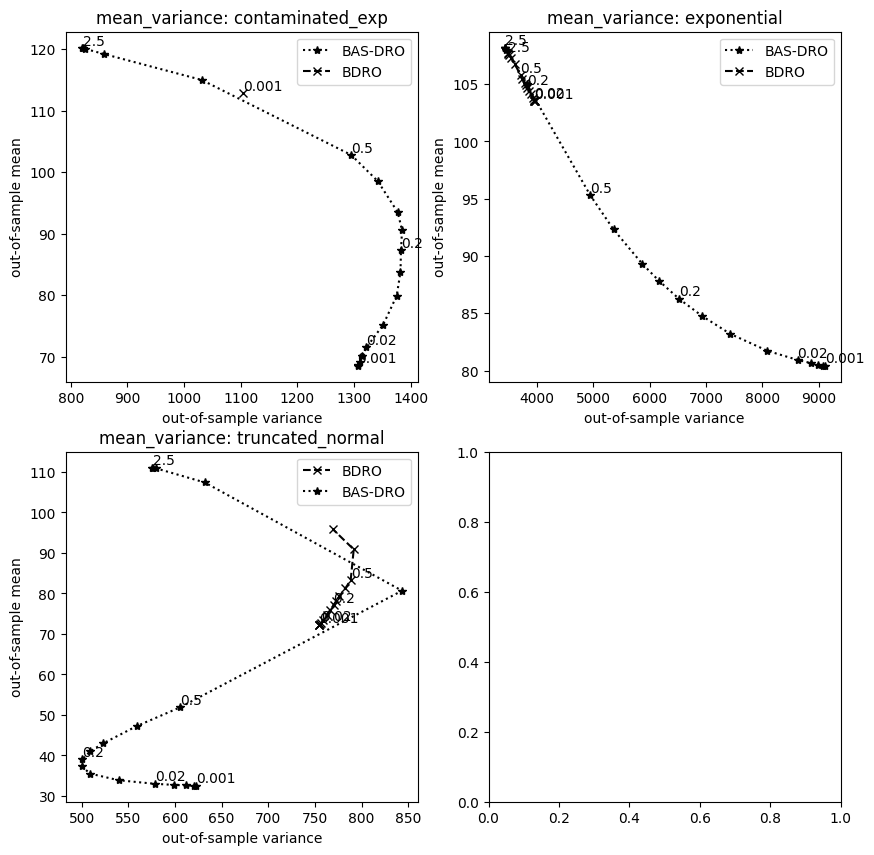

In [24]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
fig.show()

## Solve time

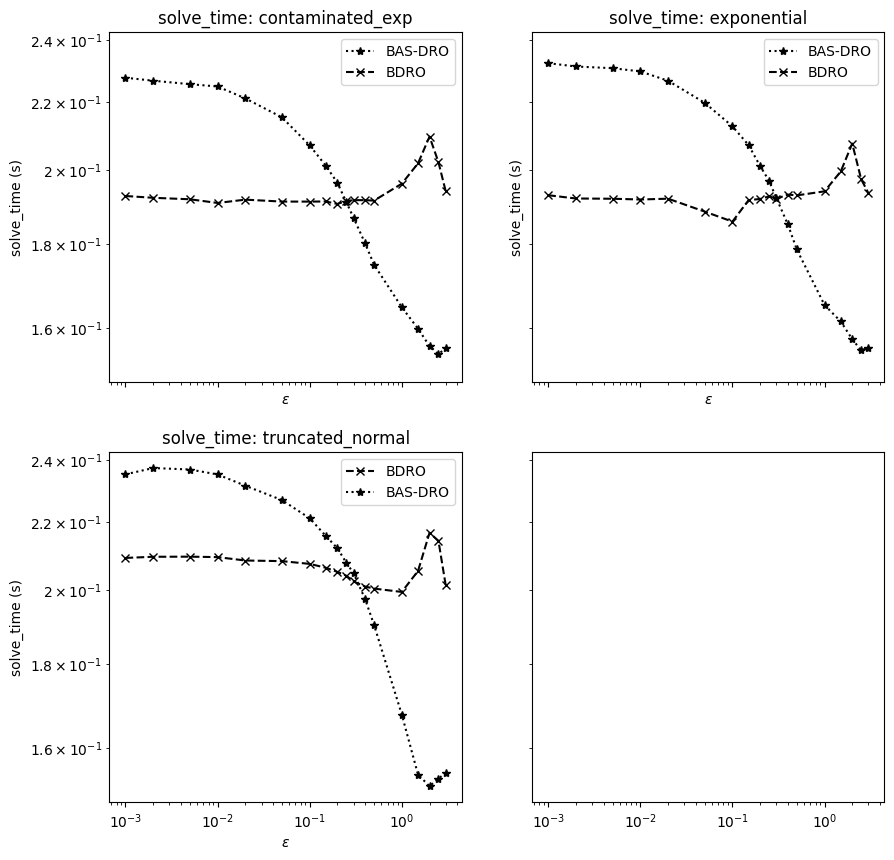

In [18]:
fig, axes = flexible_figure(agg_df, "solve_time", compare_col="algorithm", gb_col="dgp", sharex=True, sharey=True, ncols=2)
fig.show()